# Recurrent Neural Networks (RNNs)


**Author:** *Corneliu Catlabuga*

**Group:** *IS-251M*

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import (
    Input, Embedding, Dense, RNN, SimpleRNNCell,
    LSTM, GRU, Bidirectional, TextVectorization
)
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences

In [15]:
MAX_TOKENS = 10000
MAX_LEN    = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_TOKENS)

x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding='post', truncating='post')
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Train shape: {x_train.shape} | Test shape: {x_test.shape}")

EMBED_DIM = 64
UNITS     = 64
EPOCHS    = 5
BATCH     = 128

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train shape: (25000, 200) | Test shape: (25000, 200)


In [16]:
def build_simple_rnn():
    model = Sequential([
        Embedding(MAX_TOKENS, EMBED_DIM, input_length=MAX_LEN),
        RNN(SimpleRNNCell(UNITS), return_sequences=False),
        Dense(64, activation='relu'),
        Dense(1,  activation='sigmoid')
    ], name="SimpleRNN")
    return model

def build_lstm():
    model = Sequential([
        Embedding(MAX_TOKENS, EMBED_DIM, input_length=MAX_LEN),
        LSTM(UNITS),
        Dense(64, activation='relu'),
        Dense(1,  activation='sigmoid')
    ], name="LSTM")
    return model

def build_lstm_bidir():
    model = Sequential([
        Embedding(MAX_TOKENS, EMBED_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(UNITS)),
        Dense(64, activation='relu'),
        Dense(1,  activation='sigmoid')
    ], name="BiLSTM")
    return model

def build_gru():
    model = Sequential([
        Embedding(MAX_TOKENS, EMBED_DIM, input_length=MAX_LEN),
        GRU(UNITS),
        Dense(64, activation='relu'),
        Dense(1,  activation='sigmoid')
    ], name="GRU")
    return model

def build_gru_bidir():
    model = Sequential([
        Embedding(MAX_TOKENS, EMBED_DIM, input_length=MAX_LEN),
        Bidirectional(GRU(UNITS)),
        Dense(64, activation='relu'),
        Dense(1,  activation='sigmoid')
    ], name="BiGRU")
    return model


In [17]:
models_to_compare = {
    "SimpleRNN": build_simple_rnn(),
    "LSTM":      build_lstm(),
    "BiLSTM":    build_lstm_bidir(),
    "GRU":       build_gru(),
    "BiGRU":     build_gru_bidir(),
}

results = {}
histories = {}

for name, model in models_to_compare.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model.summary()

    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.1,
        verbose=1
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    results[name]   = {"loss": loss, "accuracy": acc}
    histories[name] = history
    print(f"{name} → Test Accuracy: {acc:.4f} | Test Loss: {loss:.4f}")



Training: SimpleRNN


/home/muffindud/Documents/RNIP/lab4/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_5 (RNN)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.6432 - loss: 0.6170 - val_accuracy: 0.8296 - val_loss: 0.4065
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.8531 - loss: 0.3542 - val_accuracy: 0.8480 - val_loss: 0.3536
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9001 - loss: 0.2618 - val_accuracy: 0.8456 - val_loss: 0.3590
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9226 - loss: 0.2080 - val_accuracy: 0.8504 - val_loss: 0.3837
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9436 - loss: 0.1565 - val_accuracy: 0.8492 - val_loss: 0.4504
BiGRU → Test Accuracy: 0.8276 | Test Loss: 0.5113


In [18]:
# We'll use the IMDB word index to encode custom strings
word_index = imdb.get_word_index()

def encode_review(text: str) -> np.ndarray:
    """Encode a raw string using the IMDB vocabulary."""
    words = text.lower().split()
    # index offset: 3 reserved tokens in Keras IMDB
    encoded = [word_index.get(w, 2) + 3 for w in words]
    encoded = [min(idx, MAX_TOKENS - 1) for idx in encoded]
    padded  = pad_sequences([encoded], maxlen=MAX_LEN, padding='post', truncating='post')
    return padded

test_reviews = [
    "This movie was absolutely fantastic, I loved every second of it!",
    "Terrible film. Boring plot and awful acting. Complete waste of time.",
    "It was okay, nothing special but not bad either.",
]

print("\n" + "="*50)
print("REAL-TIME PREDICTIONS")
print("="*50)

best_model = models_to_compare["BiGRU"]   # swap to whichever scored highest

for review in test_reviews:
    encoded = encode_review(review)
    score   = best_model.predict(encoded, verbose=0)[0][0]
    label   = "POSITIVE" if score >= 0.5 else "NEGATIVE"
    print(f"\nReview : {review}")
    print(f"Score  : {score:.4f} → {label}")


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

REAL-TIME PREDICTIONS

Review : This movie was absolutely fantastic, I loved every second of it!
Score  : 0.9546 → POSITIVE

Review : Terrible film. Boring plot and awful acting. Complete waste of time.
Score  : 0.0015 → NEGATIVE

Review : It was okay, nothing special but not bad either.
Score  : 0.5157 → POSITIVE


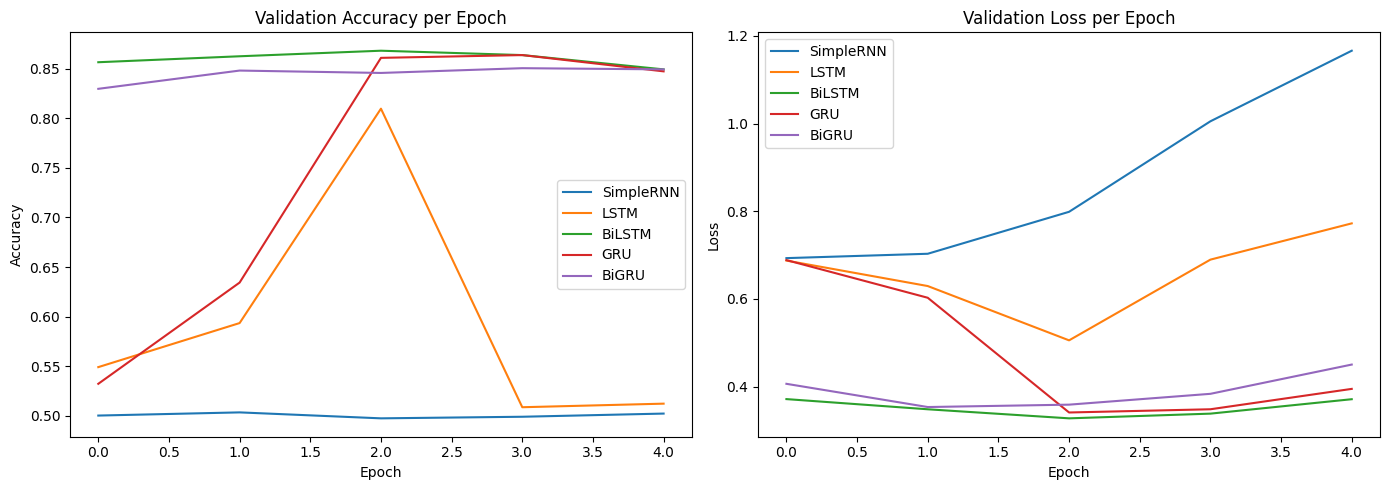

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, history in histories.items():
    axes[0].plot(history.history['val_accuracy'], label=name)
    axes[1].plot(history.history['val_loss'],     label=name)

axes[0].set_title('Validation Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].set_title('Validation Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


In [20]:
print("\n" + "="*50)
print(f"{'Model':<12} {'Test Accuracy':>14} {'Test Loss':>10}")
print("-"*38)
for name, metrics in results.items():
    print(f"{name:<12} {metrics['accuracy']:>14.4f} {metrics['loss']:>10.4f}")


Model         Test Accuracy  Test Loss
--------------------------------------
SimpleRNN            0.5058     1.1463
LSTM                 0.4999     0.7816
BiLSTM               0.8324     0.4279
GRU                  0.8351     0.4259
BiGRU                0.8276     0.5113


In [22]:
models_to_compare["SimpleRNN"].save("models/simplernn_sentiment.keras")
models_to_compare["LSTM"].save("models/lstm_sentiment.keras")
models_to_compare["BiLSTM"].save("models/bilstm_sentiment.keras")
models_to_compare["GRU"].save("models/gru_sentiment.keras")
models_to_compare["BiGRU"].save("models/bigru_sentiment.keras")